# Toxic Comment Classification System
## Using the Kaggle Jigsaw Dataset

This notebook detects and classifies toxic comments from the [Jigsaw Toxic Comment Classification Challenge](https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge) using NLP and machine learning.

### Pipeline:
1. Kaggle dataset download & loading
2. Data exploration
3. Text preprocessing
4. Feature extraction (TF-IDF & Count Vectorization)
5. Model training (Naïve Bayes & k-NN)
6. Evaluation & comparison
7. Hyperparameter tuning
8. Deployment-ready prediction service

### Setup — run this first if you haven't already:
```bash
pip install kaggle pandas numpy matplotlib seaborn scikit-learn nltk wordcloud joblib
```


In [16]:
# ── 0. Install dependencies (uncomment if needed) ──────────────────────────
# !pip install kaggle pandas numpy matplotlib seaborn scikit-learn nltk wordcloud joblib

import os, re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)
from sklearn.pipeline import Pipeline
import joblib, pickle

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
plt.style.use('ggplot')
np.random.seed(42)

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

print('All libraries loaded ✓')

All libraries loaded ✓


## 1. Download the Kaggle Dataset

**Option A – Kaggle CLI (recommended)**
```bash
kaggle competitions download -c jigsaw-toxic-comment-classification-challenge
unzip jigsaw-toxic-comment-classification-challenge.zip
```

**Option B – Manual**  
Download from https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge/data and place `train.csv` in the same folder as this notebook.

**Option C – HuggingFace (no Kaggle account needed)**
```python
from datasets import load_dataset
ds = load_dataset("google/jigsaw_toxicity_pred")
df_raw = ds['train'].to_pandas()
```

In [17]:
# ── 1. Load Data ────────────────────────────────────────────────────────────

DATA_PATH = 'train.csv'   # ← change if your file is elsewhere
SAMPLE_SIZE = 50_000      # use None to load the full ~160k rows

def load_jigsaw(path: str, sample_size: int = None) -> pd.DataFrame:
    """Load Jigsaw train.csv and create a single binary 'toxic' label."""
    df = pd.read_csv(path)

    toxic_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
    df['label'] = (df[toxic_cols].sum(axis=1) > 0).astype(int)

    df = df[['id', 'comment_text', 'label'] + toxic_cols].copy()
    df.dropna(subset=['comment_text'], inplace=True)
    df['comment_text'] = df['comment_text'].astype(str)

    if sample_size:
        toxic = df[df['label']==1].sample(min(int(sample_size*0.1), df['label'].sum()), random_state=42)
        non_toxic = df[df['label']==0].sample(min(int(sample_size*0.9), (df['label']==0).sum()), random_state=42)
        df = pd.concat([toxic, non_toxic]).sample(frac=1, random_state=42).reset_index(drop=True)

    print(f'Loaded {len(df):,} comments')
    return df

df = load_jigsaw(DATA_PATH, SAMPLE_SIZE)
df.head(3)

Loaded 50,000 comments


,id,comment_text,label,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,2d8fd9cb554a3d91,"Also, this statement in the ref you added doesn't give enough specifics, what setbacks are they talking about (damag...",0,0,0,0,0,0,0
1,423e2c9d68fe7900,"Please stop making these changes again - I explained to you the problems with them. Let's discuss it here, please.",0,0,0,0,0,0,0
2,b2ce8a88d87caf5f,"Try Android79, and DreamGuy\n\nBoth very unpopular with other Wikians, and both seem to be a%%holes, uneducated, arr...",1,1,0,1,0,1,0


=== Dataset Overview ===
Total comments : 50,000
Toxic          : 5,000 (10.0%)
Non-toxic      : 45,000 (90.0%)


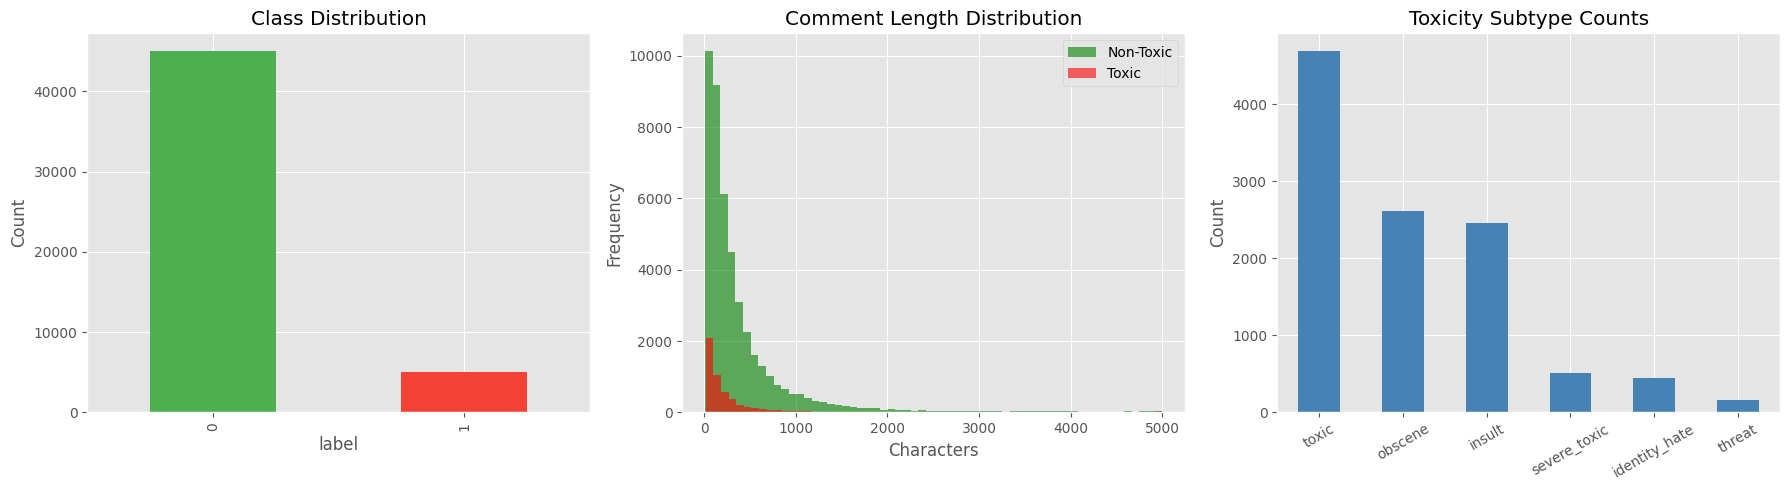


Sample toxic comments:
 - Try Android79, and DreamGuy

Both very unpopular with other Wikians, and both seem to be a%%holes, uneducated, arrogant,
 - "

 how did I ""vandalize"" the joke page on Osama Bin Laden exactly ? 

care to elaborate ? plus it was on the frikking
 - Yeah that's quite laughable.  You need to count correctly and learn how to use the history page correctly.  As the insti

Sample non-toxic comments:
 - Also, this statement in the ref you added doesn't give enough specifics, what setbacks are they talking about (damage to
 - Please stop making these changes again - I explained to you the problems with them. Let's discuss it here, please.
 - "
Got a source for that? Talk "


In [19]:
# ── 2. Exploratory Data Analysis ────────────────────────────────────────────

def explore_data(df: pd.DataFrame):
    toxic_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

    print('=== Dataset Overview ===')
    print(f'Total comments : {len(df):,}')
    print(f'Toxic          : {df["label"].sum():,} ({df["label"].mean()*100:.1f}%)')
    print(f'Non-toxic      : {(df["label"]==0).sum():,} ({(df["label"]==0).mean()*100:.1f}%)')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Class distribution
    df['label'].value_counts().plot(
        kind='bar', ax=axes[0], color=['#4CAF50', '#F44336'],
        tick_label=['Non-Toxic', 'Toxic']
    )
    axes[0].set_title('Class Distribution')
    axes[0].set_ylabel('Count')

    # Comment length distribution
    df['char_len'] = df['comment_text'].str.len()
    for label, color, name in [(0, 'green', 'Non-Toxic'), (1, 'red', 'Toxic')]:
        df[df['label']==label]['char_len'].plot(
            kind='hist', bins=60, alpha=0.6, ax=axes[1], color=color, label=name
    )
    axes[1].set_title('Comment Length Distribution')
    axes[1].set_xlabel('Characters')
    axes[1].legend()

    # Toxicity subtype counts
    subtype_counts = df[toxic_cols].sum().sort_values(ascending=False)
    subtype_counts.plot(kind='bar', ax=axes[2], color='steelblue')
    axes[2].set_title('Toxicity Subtype Counts')
    axes[2].set_ylabel('Count')
    axes[2].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()

    print('\nSample toxic comments:')
    for t in df[df['label']==1]['comment_text'].head(3):
        print(' -', t[:120])

    print('\nSample non-toxic comments:')
    for t in df[df['label']==0]['comment_text'].head(3):
        print(' -', t[:120])

explore_data(df)

In [20]:
# ── 3. Text Preprocessing ───────────────────────────────────────────────────

class TextPreprocessor:
    """Configurable NLP preprocessing pipeline."""

    def __init__(self, stem: bool = True, remove_stopwords: bool = True,
                 custom_stopwords: list = None):
        self.stemmer = PorterStemmer() if stem else None
        self.stop_words = set(stopwords.words('english')) if remove_stopwords else set()
        if custom_stopwords:
            self.stop_words |= set(custom_stopwords)

    def preprocess(self, text: str) -> str:
        text = text.lower()
        text = re.sub(r'http\S+|www\S+|https\S+|@\w+', ' ', text)   # URLs & mentions
        text = re.sub(r'[^\w\s]', ' ', text)                          # punctuation
        text = re.sub(r'\d+', ' ', text)                              # numbers
        text = re.sub(r'\s+', ' ', text).strip()                      # extra whitespace

        tokens = word_tokenize(text)
        tokens = [t for t in tokens if t not in self.stop_words and len(t) > 1]
        if self.stemmer:
            tokens = [self.stemmer.stem(t) for t in tokens]

        return ' '.join(tokens)


preprocessor = TextPreprocessor(stem=True, remove_stopwords=True)

print('Preprocessing comments — this may take a minute...')
df['processed_text'] = df['comment_text'].apply(preprocessor.preprocess)
print('Done ✓')

# Show before/after
sample = df[['comment_text', 'processed_text']].sample(3, random_state=1)
for _, row in sample.iterrows():
    print('\nOriginal :', row['comment_text'][:120])
    print('Processed:', row['processed_text'][:120])

Preprocessing comments — this may take a minute...
Done ✓

Original : WOW is commenting on your comment to me and asking a question a personal attack now a days. Basically you're saying that
Processed: wow comment comment ask question person attack day basic say type anyth tell disagre attack pathet realli wow wikipedia 

Original : Having reviewed that statement, I see it contained yet another legal threat.  You are blocked indefinitely. 96
Processed: review statement see contain yet anoth legal threat block indefinit

Original : "

 ""Palestinian"" in title should be changed to ""Gaza inhabitants"" 

Not everybody in Gaza is Palestinian. So I gues
Processed: palestinian titl chang gaza inhabit everybodi gaza palestinian guess casualti palestinian


In [21]:
# ── 4. Feature Extraction ───────────────────────────────────────────────────

MAX_FEATURES = 10_000

def create_features(df: pd.DataFrame, max_features: int = MAX_FEATURES) -> dict:
    """Build TF-IDF and Count feature matrices with a stratified 80/20 split."""

    X = df['processed_text']
    y = df['label']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    vectorizers = {
        'tfidf': TfidfVectorizer(max_features=max_features, ngram_range=(1, 2),
                                  min_df=3, max_df=0.95, sublinear_tf=True),
        'count': CountVectorizer(max_features=max_features, ngram_range=(1, 2),
                                  min_df=3, max_df=0.95)
    }

    result = {'y_train': y_train, 'y_test': y_test,
              'X_train_text': X_train, 'X_test_text': X_test}

    for name, vec in vectorizers.items():
        result[name] = {
            'train'     : vec.fit_transform(X_train),
            'test'      : vec.transform(X_test),
            'vectorizer': vec
        }
        print(f'{name.upper()} — train: {result[name]["train"].shape}, '
              f'test: {result[name]["test"].shape}')

    return result


features = create_features(df)
print('\nSample TF-IDF features:', features['tfidf']['vectorizer'].get_feature_names_out()[:15])

TFIDF — train: (40000, 10000), test: (10000, 10000)
COUNT — train: (40000, 10000), test: (10000, 10000)

Sample TF-IDF features: ['aa' 'aaron' 'ab' 'abandon' 'abbrevi' 'abc' 'abid' 'abil' 'abl'
 'abl edit' 'abl find' 'abl get' 'abl help' 'abl see' 'abolish']



=== TFIDF | train: 40,000, test: 10,000 ===

Training Naive Bayes...
              precision    recall  f1-score   support

   Non-Toxic       0.95      1.00      0.97      9000
       Toxic       0.95      0.51      0.66      1000

    accuracy                           0.95     10000
   macro avg       0.95      0.75      0.82     10000
weighted avg       0.95      0.95      0.94     10000



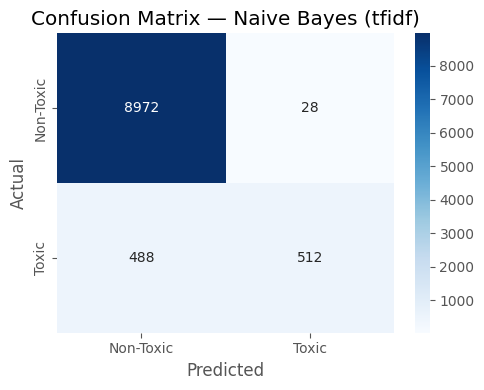


Training k-NN...
              precision    recall  f1-score   support

   Non-Toxic       0.95      0.99      0.97      9000
       Toxic       0.80      0.51      0.62      1000

    accuracy                           0.94     10000
   macro avg       0.87      0.75      0.79     10000
weighted avg       0.93      0.94      0.93     10000



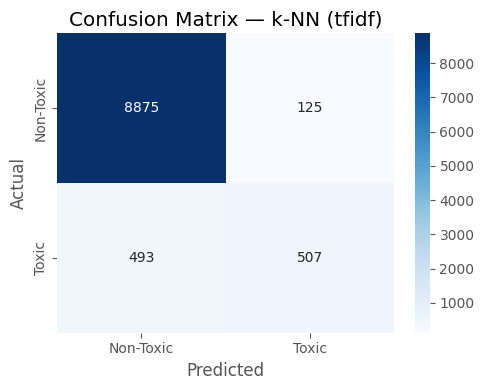


=== COUNT | train: 40,000, test: 10,000 ===

Training Naive Bayes...
              precision    recall  f1-score   support

   Non-Toxic       0.97      0.97      0.97      9000
       Toxic       0.75      0.71      0.73      1000

    accuracy                           0.95     10000
   macro avg       0.86      0.84      0.85     10000
weighted avg       0.95      0.95      0.95     10000



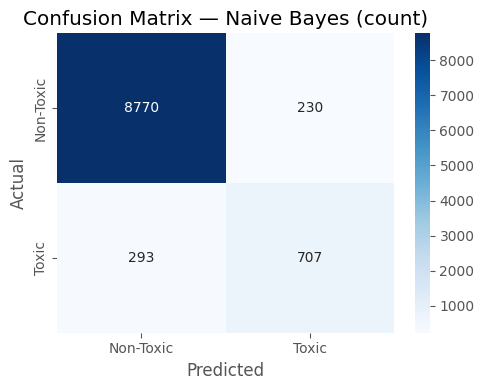


Training k-NN...
              precision    recall  f1-score   support

   Non-Toxic       0.94      0.99      0.96      9000
       Toxic       0.83      0.38      0.52      1000

    accuracy                           0.93     10000
   macro avg       0.88      0.69      0.74     10000
weighted avg       0.93      0.93      0.92     10000



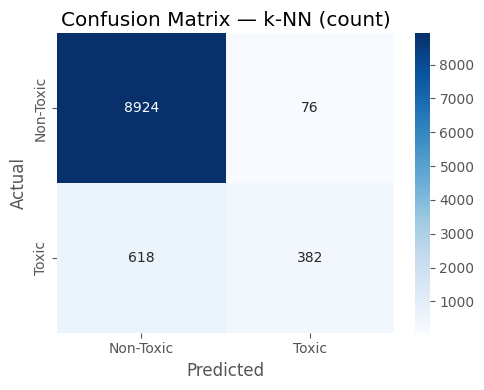

In [22]:
# ── 5. Model Training & Evaluation ─────────────────────────────────────────

class CommentClassifier:
    """Train and evaluate Naïve Bayes and k-NN on both feature sets."""

    def __init__(self):
        self.models = {
            'Naive Bayes': MultinomialNB(alpha=0.5),
            'k-NN'       : KNeighborsClassifier(n_neighbors=5, metric='cosine',
                                                 algorithm='brute', n_jobs=-1)
        }
        self.results = {}

    def train_and_evaluate(self, features: dict, feature_type: str = 'tfidf'):
        X_train = features[feature_type]['train']
        X_test  = features[feature_type]['test']
        y_train = features['y_train']
        y_test  = features['y_test']

        print(f'\n=== {feature_type.upper()} | train: {X_train.shape[0]:,}, '
              f'test: {X_test.shape[0]:,} ===')

        for name, model in self.models.items():
            print(f'\nTraining {name}...')
            try:
                model.fit(X_train, y_train)
                y_pred  = model.predict(X_test)
                y_proba = model.predict_proba(X_test)[:, 1] \
                          if hasattr(model, 'predict_proba') else None

                key = f'{name} ({feature_type})'
                self.results[key] = {
                    'accuracy' : accuracy_score(y_test, y_pred),
                    'precision': precision_score(y_test, y_pred),
                    'recall'   : recall_score(y_test, y_pred),
                    'f1'       : f1_score(y_test, y_pred),
                    'cm'       : confusion_matrix(y_test, y_pred),
                    'y_proba'  : y_proba,
                    'model'    : model
                }

                print(classification_report(y_test, y_pred,
                      target_names=['Non-Toxic', 'Toxic']))
                self._plot_cm(self.results[key]['cm'], key)

            except Exception as e:
                print(f'  ✗ Failed: {e}')

    def _plot_cm(self, cm, title):
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Non-Toxic', 'Toxic'],
                    yticklabels=['Non-Toxic', 'Toxic'])
        plt.title(f'Confusion Matrix — {title}')
        plt.xlabel('Predicted'); plt.ylabel('Actual')
        plt.tight_layout(); plt.show()


classifier = CommentClassifier()
classifier.train_and_evaluate(features, 'tfidf')
classifier.train_and_evaluate(features, 'count')

=== Performance Summary ===
                     Accuracy  Precision  Recall      F1
Model                                                   
Naive Bayes (tfidf)    0.9484     0.9481   0.512  0.6649
k-NN (tfidf)           0.9382     0.8022   0.507  0.6213
Naive Bayes (count)    0.9477     0.7545   0.707  0.7300
k-NN (count)           0.9306     0.8341   0.382  0.5240


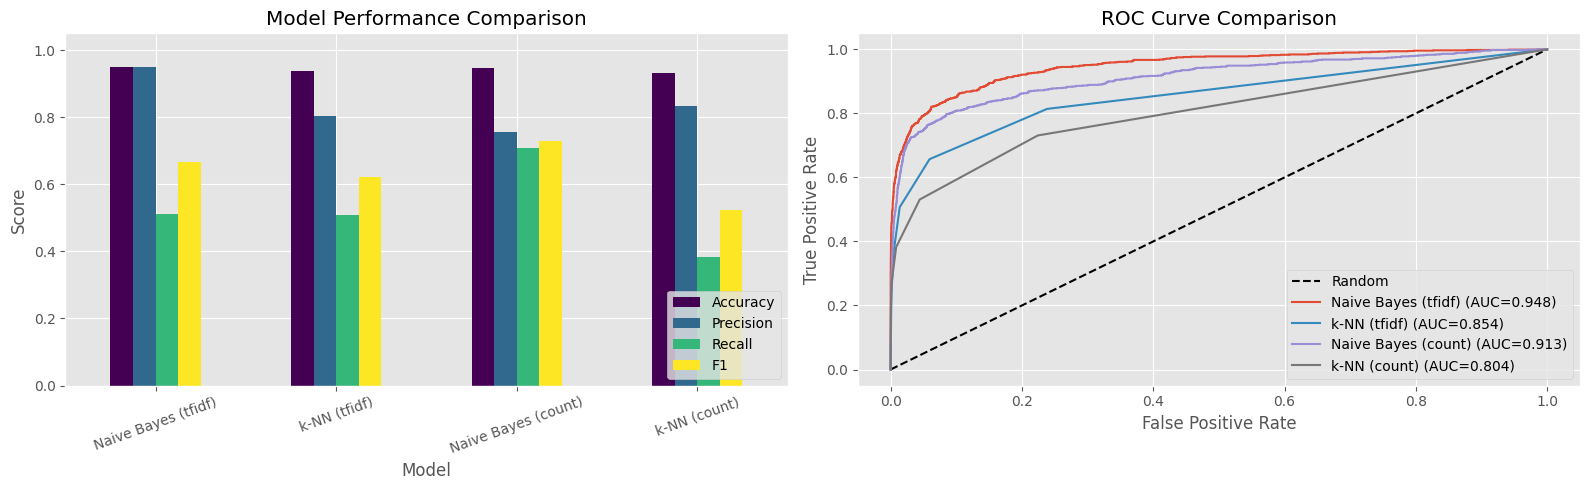

In [23]:
# ── 6. Model Comparison & ROC Curves ───────────────────────────────────────

def compare_models(results: dict, y_test):
    # Performance table
    rows = []
    for key, m in results.items():
        rows.append({'Model': key, 'Accuracy': m['accuracy'],
                     'Precision': m['precision'], 'Recall': m['recall'], 'F1': m['f1']})
    perf = pd.DataFrame(rows).set_index('Model')

    print('=== Performance Summary ===')
    print(perf.round(4).to_string())

    # Bar chart
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    perf.plot(kind='bar', ax=axes[0], rot=20, colormap='viridis')
    axes[0].set_title('Model Performance Comparison')
    axes[0].set_ylabel('Score')
    axes[0].set_ylim(0, 1.05)
    axes[0].legend(loc='lower right')

    # ROC curves
    axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
    for key, m in results.items():
        if m['y_proba'] is not None:
            fpr, tpr, _ = roc_curve(y_test, m['y_proba'])
            auc = roc_auc_score(y_test, m['y_proba'])
            axes[1].plot(fpr, tpr, label=f'{key} (AUC={auc:.3f})')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve Comparison')
    axes[1].legend(loc='lower right')

    plt.tight_layout(); plt.show()
    return perf

perf_df = compare_models(classifier.results, features['y_test'])

In [24]:
# ── 7. Hyperparameter Tuning (Naïve Bayes + TF-IDF) ────────────────────────

def tune_naive_bayes(X_train_text, y_train):
    """Grid search over TF-IDF + Naïve Bayes pipeline."""
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(sublinear_tf=True)),
        ('nb'   , MultinomialNB())
    ])

    param_grid = {
        'tfidf__max_features': [5_000, 10_000],
        'tfidf__ngram_range' : [(1, 1), (1, 2)],
        'nb__alpha'          : [0.1, 0.5, 1.0]
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    grid = GridSearchCV(pipeline, param_grid, cv=cv,
                        scoring='f1', verbose=1, n_jobs=-1)
    grid.fit(X_train_text, y_train)

    print('Best params :', grid.best_params_)
    print('Best F1     :', round(grid.best_score_, 4))
    return grid.best_estimator_

best_model = tune_naive_bayes(
    features['X_train_text'],
    features['y_train']
)
print('\nTuned model:', best_model)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params : {'nb__alpha': 0.1, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
Best F1     : 0.6646

Tuned model: Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('nb', MultinomialNB(alpha=0.1))])


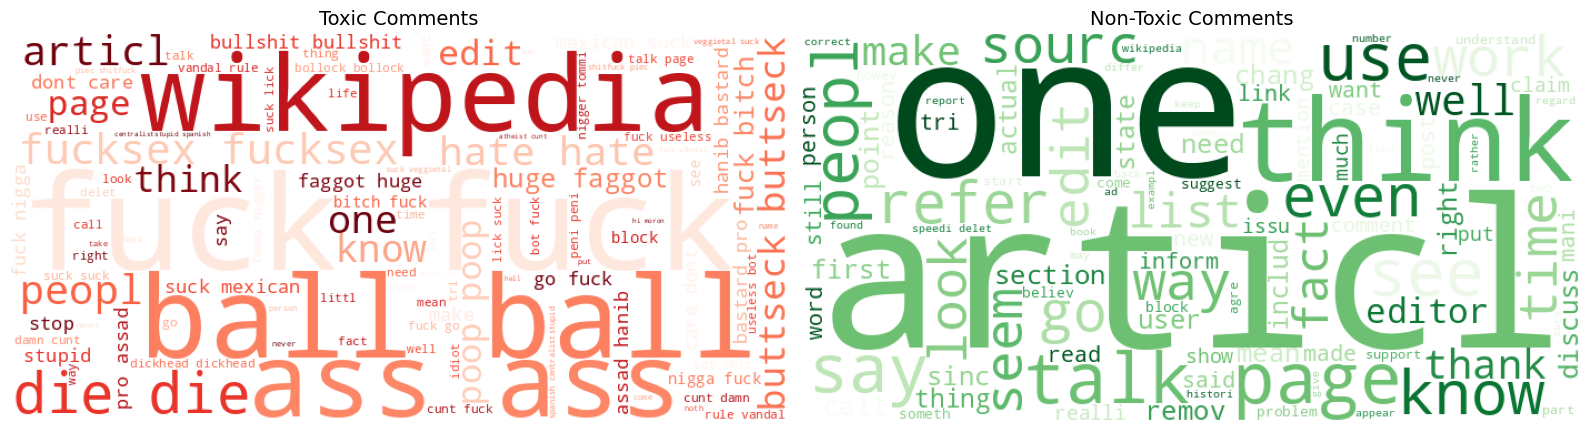

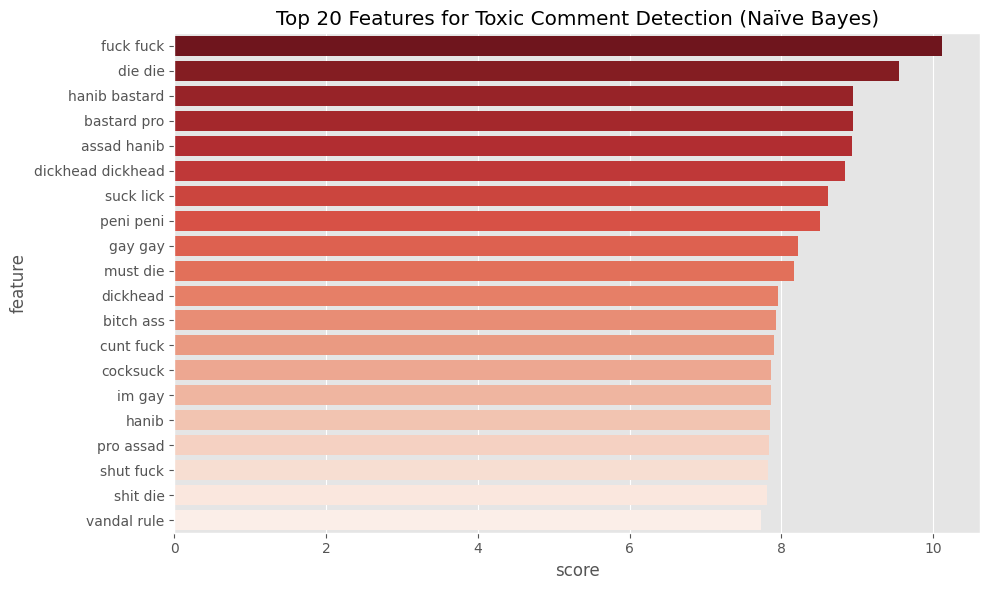

In [25]:
# ── 8. Visualisations ───────────────────────────────────────────────────────

def make_wordclouds(df: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for ax, label, title, color in [
        (axes[0], 1, 'Toxic Comments',     'Reds'),
        (axes[1], 0, 'Non-Toxic Comments', 'Greens')
    ]:
        text = ' '.join(df[df['label'] == label]['processed_text'])
        wc = WordCloud(width=700, height=350, background_color='white',
                       colormap=color, max_words=100).generate(text)
        ax.imshow(wc); ax.axis('off'); ax.set_title(title, fontsize=14)

    plt.tight_layout(); plt.show()


def plot_top_features(model, vectorizer, n: int = 20):
    """Bar chart of top discriminative features from Naïve Bayes."""
    if not hasattr(model, 'feature_log_prob_'):
        print('Feature importance only available for Naïve Bayes.')
        return

    importance = model.feature_log_prob_[1] - model.feature_log_prob_[0]
    feat_names = vectorizer.get_feature_names_out()
    top = pd.DataFrame({'feature': feat_names, 'score': importance}) \
            .nlargest(n, 'score')

    plt.figure(figsize=(10, 6))
    sns.barplot(x='score', y='feature', data=top, palette='Reds_r')
    plt.title(f'Top {n} Features for Toxic Comment Detection (Naïve Bayes)')
    plt.tight_layout(); plt.show()


make_wordclouds(df)
plot_top_features(
    classifier.results['Naive Bayes (tfidf)']['model'],
    features['tfidf']['vectorizer']
)

In [26]:
# ── 9. Save & Load Model ────────────────────────────────────────────────────

MODEL_PATH = 'toxic_nb_model.joblib'
VEC_PATH   = 'toxic_tfidf_vectorizer.pkl'

def save_model(model, vectorizer, model_path=MODEL_PATH, vec_path=VEC_PATH):
    joblib.dump(model, model_path)
    with open(vec_path, 'wb') as f:
        pickle.dump(vectorizer, f)
    print(f'Model saved     → {model_path}')
    print(f'Vectorizer saved → {vec_path}')

def load_model(model_path=MODEL_PATH, vec_path=VEC_PATH):
    model = joblib.load(model_path)
    with open(vec_path, 'rb') as f:
        vectorizer = pickle.load(f)
    return model, vectorizer

save_model(
    classifier.results['Naive Bayes (tfidf)']['model'],
    features['tfidf']['vectorizer']
)

Model saved     → toxic_nb_model.joblib
Vectorizer saved → toxic_tfidf_vectorizer.pkl


In [27]:
# ── 10. Prediction Service ──────────────────────────────────────────────────

class PredictionService:
    """Wraps preprocessing + vectorizer + model for single-comment inference."""

    def __init__(self, model, vectorizer, preprocessor):
        self.model        = model
        self.vectorizer   = vectorizer
        self.preprocessor = preprocessor

    def predict(self, text: str) -> dict:
        processed  = self.preprocessor.preprocess(text)
        vectorized = self.vectorizer.transform([processed])
        pred       = self.model.predict(vectorized)[0]
        proba      = self.model.predict_proba(vectorized)[0]

        return {
            'prediction'            : 'Toxic' if pred == 1 else 'Non-Toxic',
            'probability_toxic'     : round(float(proba[1]), 4),
            'probability_non_toxic' : round(float(proba[0]), 4)
        }

    def predict_batch(self, texts: list) -> pd.DataFrame:
        return pd.DataFrame([self.predict(t) for t in texts])


service = PredictionService(
    model        = classifier.results['Naive Bayes (tfidf)']['model'],
    vectorizer   = features['tfidf']['vectorizer'],
    preprocessor = preprocessor
)

# Try it out
test_comments = [
    "You are a wonderful person, thank you for your help!",
    "I hope you suffer for this, you absolute idiot.",
    "This is a pretty reasonable point, I mostly agree.",
    "Go away, nobody wants you here."
]

results_df = service.predict_batch(test_comments)
results_df.insert(0, 'comment', test_comments)
print(results_df.to_string(index=False))

                                             comment prediction  probability_toxic  probability_non_toxic
You are a wonderful person, thank you for your help!  Non-Toxic             0.0107                 0.9893
     I hope you suffer for this, you absolute idiot.  Non-Toxic             0.3585                 0.6415
  This is a pretty reasonable point, I mostly agree.  Non-Toxic             0.0151                 0.9849
                     Go away, nobody wants you here.  Non-Toxic             0.3912                 0.6088
